# Trajectory Examples
1. Generation with moon (or custom body)
2. EKF on simply noisy position measurements
3. UKF on simply noisy position measurements
4. PF on simply noisy position measurements? idk idk

In [14]:
from pathlib import Path
import sys
parent_dir = Path.cwd().parent.resolve()
sys.path.append(str(parent_dir))

In [15]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

from trajectory.orbit import OrbitPropagator
from trajectory.Constants import G, Luna, ARCSEC_TO_RAD, RAD_TO_ARCSEC, RAD_TO_DEG
from utils import circle_points, noise
from filters import SatEKF

## Generation

In [16]:
body = Luna # could be moon

body = { # Custom central body
    "radius": 3000, # km
    "mass": 6e23, # kg
    "mu": 6e23 * G,
    "position": [0,0,0]
}

body = Luna # could be moon
body["position"] = [0,0,0]

# State
r = 1500 + body["radius"]
v = np.sqrt(body["mu"] / r) + 0.3 # km/s, slightly above circular velocity
state0 = np.array([
    r, 0, 0,
    0, v, 0])

# Time
dt = 1

# Simulating Half an orbit
orb_period = 2 * np.pi * np.sqrt(r*r*r/body["mu"])
print(f"Orbital period (T): {orb_period}s")
tf = orb_period * 10

Orbital period (T): 16525.074464841775s


In [17]:
# Propagator
op = OrbitPropagator(state0, tf, dt, [body])
op.simulate()

In [18]:
print(f"Final state: {len(op.states)}")

Final state: 165252


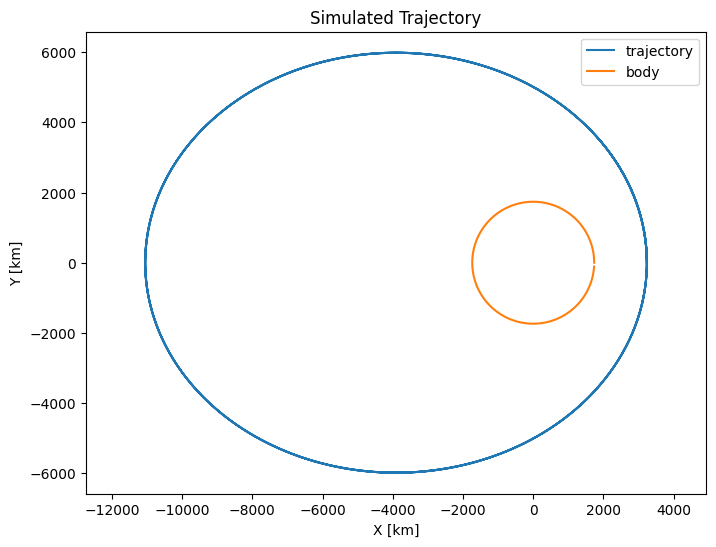

In [19]:
plt.figure(figsize=(8, 6))

plt.title("Simulated Trajectory")
plt.plot(op.states[:,0], op.states[:,1])
plt.plot(*circle_points(body["radius"], position=body["position"][0:2]))
plt.xlabel("X [km]")
plt.ylabel("Y [km]")
plt.legend(["trajectory", "body"])
plt.axis('equal')
plt.show()

## EKF on position measurements



In [20]:
# def simulate_camera_meas(r_p, )

def simulate_camera_meas(state: np.ndarray, R: np.ndarray, sigma_angle_perturb: float):
    """
    Simulate a camera measurement of a planet from a satellite.
    
    Parameters
    ----------
    state : np.ndarray, shape (3)
        Satellite state vector in planet frame (P->C).
    R : np.ndarray, shape (3,3)
        Measurement cov. matrix
    sigma_angle_perturb : float
        1-sigma measurement uncertainty of rotation matrix angular offset (for return value T_p_c)
    
    Returns
    -------
    r_c_meas : np.ndarray, shape (3,)
        Simulated measurement vector in camera frame (from camera to planet center), including noise.
    T_c_p : np.ndarray, shape (3,3)
        The TRUTH Rotation matrix from planet frame to camera frame.
    """
    
    rho_p = state[0:3]
    v_p = state[3:6]
    r_norm = np.linalg.norm(rho_p)
    r_c_unit = -rho_p / r_norm  # z-axis points toward planet (C->P)
    
    # ---------- Pick arbitrary x-axis perpendicular to z ----------

    x_cam = np.cross(rho_p, v_p)  # Cross with planet's z for equatorial x
    if np.linalg.norm(x_cam) < 1e-10:  # Degeneracy if r_c_unit is along z
        x_cam = np.cross([1, 0, 0], r_c_unit)  # Fallback to planet x

    x_cam /= norm(x_cam)
    y_cam = np.cross(r_c_unit, x_cam)
    
    # ---------- Define a rotation matrix T_p_c ----------
    T_c_p = np.column_stack((x_cam, y_cam, r_c_unit))  # rotates vector from planet->camera frame
    
        # ---------- Perturb T_p_c with angular uncertainty ----------
    # Generate a small random rotation axis and angle
    axis = np.random.normal(0, 1, 3)
    axis /= np.linalg.norm(axis)  # Unit axis
    angle = np.random.normal(0, sigma_angle_perturb)  # Perturbed angle
    # Apply Rodrigues' rotation for small angle approximation 
    # https://en.wikipedia.org/wiki/Rodrigues%27_rotation_formula#Matrix_notation
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    T_c_p_perturbed = T_c_p @ (np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * K @ K)
    
    # ---------- Transform true vector into camera frame with noise ----------
    r_c_true = T_c_p_perturbed @ rho_p  # P->C in camera frame
    
    # Noise yay
    r_c_meas = r_c_true + noise(R)
    
    return r_c_meas, T_c_p

In [21]:
# Q noise
factor = 100
sigma_a = 1e-2 * factor  # km/s^2
Q = np.block([
    [ (dt**3/3) * sigma_a**2 * np.eye(3), (dt**2/2) * sigma_a**2 * np.eye(3) ],
    [ (dt**2/2) * sigma_a**2 * np.eye(3), dt * sigma_a**2 * np.eye(3) ]
])

# R noise
factor = 1000
sigma_boresight = 10 * ARCSEC_TO_RAD * factor       
sigma_cross_boresight = 2 * ARCSEC_TO_RAD * factor

r_cp = norm(state0[0:3])  # example: 20,000 km distance approx, assuming it doesn't change

sigma_boresight_km = np.tan(sigma_boresight) * r_cp
sigma_cross_boresight_km    = np.tan(sigma_cross_boresight) * r_cp

R = np.diag([sigma_cross_boresight_km**2, sigma_cross_boresight_km**2, sigma_boresight_km**2])

In [22]:
mu0 = state0 + noise(Q) + np.array([100, 100, 1000, 0.1, 0.1, 0.1]) # Add some large initial error
Sigma0 = np.eye(6)
sigma_angle_perturb = 5*ARCSEC_TO_RAD

ekf = SatEKF(Q, R, dt, mu0, Sigma0, body["mass"])

measurement_frequency = 1_000 # steps

In [23]:
N = len(op.states)

mu_arr = np.zeros((N+1, 6))
Sigma_arr = np.zeros((N+1, 6, 6))
meas_arr = np.zeros((N+1, 3))
T_c_p_arr = np.zeros((N+1, 3, 3)) 
r_c_true_arr = np.zeros((N+1, 3))

mu_arr[0] = mu0
Sigma_arr[0] = Sigma0
meas_arr[0], T_c_p_arr[0] = simulate_camera_meas(state0, R, sigma_angle_perturb)
r_c_true_arr[0] = T_c_p_arr[0] @ mu0[0:3]



for i in range(N):
    # Simulate measurement
    rho_p = op.states[i, 0:3] - body["position"]  # P->C in planet frame
    r_c_meas, T_c_p_true = simulate_camera_meas(op.states[i], R, sigma_angle_perturb)
    
    # EKF update
    ekf.predict()

    if i % measurement_frequency == 0:
        print(f"Step {i}/{N} with measurement")
        ekf.update(r_c_meas, T_c_p_true)
    
    mu_arr[i+1] = ekf.mu
    Sigma_arr[i+1] = ekf.sigma
    meas_arr[i+1] = r_c_meas
    T_c_p_arr[i+1] = T_c_p_true
    r_c_true_arr[i+1] = -T_c_p_true @ rho_p

Step 0/165252 with measurement
Measurement function output: [-998.50581797  102.20681395 3334.79431516]
Step 1000/165252 with measurement
Measurement function output: [ 519.72953815 2231.37570171 1629.96076342]
Step 2000/165252 with measurement
Measurement function output: [-1660.21295623  1890.6070685   2995.56000053]
Step 3000/165252 with measurement
Measurement function output: [-3759.87845851  1304.98527197  1526.36701943]
Step 4000/165252 with measurement
Measurement function output: [-4532.39130624   735.82305351   525.66964643]
Step 5000/165252 with measurement
Measurement function output: [-5177.42503773  -441.91066887  -625.92022495]
Step 6000/165252 with measurement
Measurement function output: [-5548.98675451 -1369.72350394 -1348.09777664]
Step 7000/165252 with measurement
Measurement function output: [-5437.67687889 -2071.12078641 -2620.17623994]
Step 8000/165252 with measurement
Measurement function output: [-5010.74458453 -2764.66328981 -2561.75503627]
Step 9000/165252 wi

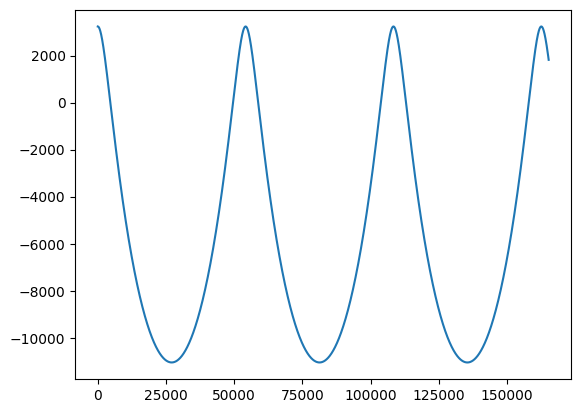

In [27]:
plt.plot(op.states[:, 0], label="True x")

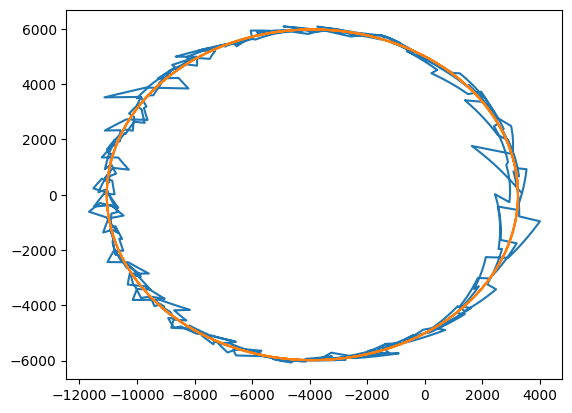

In [24]:
plt.plot(mu_arr[:,0], mu_arr[:,1])
plt.plot(op.states[:,0], op.states[:,1])